In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


EDA Supporting Functions:

In [2]:
def get_feat_type(df: pd.DataFrame, target_col: str = 'Attack Type'):
    # Select numerical columns except the target
    num_feat = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != target_col
    ]

    # Select categorical (object-type) columns except the target
    cate_feat = [
        col for col in df.select_dtypes(include=['object']).columns
        if col != target_col
    ]

    return num_feat, cate_feat

In [3]:
def corre_anlysis(df, num_feat, threshold=0.85):
    # Compute correlation matrix
    corr_matrix = df[num_feat].corr()

    # Upper triangle mask to avoid duplicate pairs
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    # Plot correlation heatmap
    plt.figure(figsize=(20, 20))
    sns.heatmap(
        corr_matrix,
        annot=False,
        cmap='coolwarm',
        center=0,
        linewidth=0.5
    )
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    # Identify highly correlated feature pairs
    high_corr = [
        (corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
        for i, j in zip(*np.where((np.abs(corr_matrix) > threshold) & mask))
    ]

    return high_corr

In [4]:
def analyze_variance_homogeneity(df, numerical_features, target_col='Attack Type'):
    results_levene = {}
    grouped = df.groupby(target_col)

    for feat in numerical_features:  # Changed from 'feature' to 'feat'
        groups = [
            group[feat].dropna().values
            for _, group in grouped
            if len(group[feat].dropna()) > 0
               and np.var(group[feat].dropna()) > 0
        ]

        if len(groups) < 2:
            print(f"Skipping Levene's test for feature: {feat} (insufficient valid groups)")
            continue

        stat, p_value = stats.levene(*groups)
        results_levene[feat] = {
            'Statistic': stat,
            'p-value': p_value
        }

    return results_levene

In [5]:
# 4. Feature importance analysis (df, num_feat, target_col='Attack Type') – Kruskal-Wallis -> df with H-statistics and p-values
def analyze_feature_importance(df, num_feat, target_col='Attack Type'): 

    h_scores = {}  
    
    for feature in num_feat:  
        # Group data by y and perform the Kruskal-Wallis test  
        groups = [group[feature].dropna().values for name, group in df.groupby(target_col)]  
        h_stat, p_val = stats.kruskal(*groups)  
        h_scores[feature] = {'H-statistic': h_stat, 'p-value': p_val}  

    # Create a DataFrame from the results  
    h_scores_df = pd.DataFrame.from_dict(h_scores, orient='index')  
    h_scores_df = h_scores_df.sort_values('H-statistic', ascending=False)  

    # Plotting H-statistics  
    plt.figure(figsize=(18, 10))  
    plt.bar(range(len(h_scores_df)), h_scores_df['H-statistic'], color='skyblue')  
    plt.xticks(range(len(h_scores_df)), h_scores_df.index, rotation=90)  
    plt.title('Feature Importance based on H-statistic (Kruskal-Wallis Test)')  
    plt.xlabel('Features')  
    plt.ylabel('H-statistic')  
    plt.tight_layout()  
    plt.show()  

    return h_scores_df

In [6]:
# 5. Feature importance analysis(df, num_feat, target_col='Attack Type') – Tree Model -> df with features ordered by importance; confusion matrix; labels; cv_scores
def analyze_feature_importance_rf(df, num_feat, target_col='Attack Type'):
    # Hyperparameters are chosen to balance performance and computational cost
    hyperparameters = {
        'n_estimators': 100,     # Number of trees (reduced for faster training)
        'max_depth': 20,         # Limit tree depth to reduce overfitting
        'min_samples_split': 5,  # Minimum samples to split an internal node
        'random_state': 42,      # Reproducibility
        'n_jobs': -1             # Use all available CPU cores
}

    # Prepare the data
    X = df[num_feat]
    y = df[target_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=hyperparameters['random_state'], stratify=y)

    # Create the Random Forest model with specified hyperparameters
    rf = RandomForestClassifier(**hyperparameters)

    # Fit the model on the training set
    rf.fit(X_train, y_train)

    # Cross-validation on the training set - reduced folds for speed
    cv_scores = cross_val_score(rf, X_train, y_train, cv=3, n_jobs=-1)
    print(f'Cross-Validation Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
    
    # Predict on test set
    y_pred = rf.predict(X_test)

    # Feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': num_feat, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    # Confusion matrix
    rf_labels = rf.classes_
    cm = confusion_matrix(y_test, y_pred)

    # Calculate test scores
    report = classification_report(y_test, y_pred, target_names=rf_labels)
    print("\nClassification Report:\n")
    print(report, end='\n\n')

    # Plot feature importances
    plt.figure(figsize=(18, 12))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.title('Feature Importance from Random Forest')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return feature_importance_df, cm, rf_labels, cv_scores

In [7]:
# 6. Calculation of the percentage of outliers for each feature (df) – IQR -> dict with outliers percentage
def calculate_outliers_percentage(df):
    outlierPercent = {}
    
    # Calculate quantiles for all columns at once
    quartiles = df.quantile([0.25, 0.75])
    total_rows = len(df)
    
    for column in df.columns:
        # Extract Q1 and Q3 from pre-calculated quartiles
        Q1 = quartiles.loc[0.25, column]
        Q3 = quartiles.loc[0.75, column]
        IQR = Q3 - Q1
        
        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Create boolean mask for outliers
        is_outlier = (df[column] < lower_bound) | (df[column] > upper_bound)
        
        # Count and calculate percentage
        outlier_percentage = (is_outlier.sum() / total_rows) * 100
        
        outlierPercent[column] = outlier_percentage

    return outlierPercent

# 1. Khám phá dữ liệu sơ bộ toàn cục
- Nạp và hợp nhất các tập dữ liệu thành phần của CICIDS2017
- Kiểm tra kích thước, cấu trúc và kiểu dữ liệu
- Đánh giá sơ bộ tình trạng dữ liệu thiếu

## 1.1. Nạp dữ liệu đầu vào

In [8]:
# 1.1 Load raw CSV files
dfs = []

read_csv = pd.read_csv
join_path = os.path.join

# Try using pyarrow engine if available (faster for large CSVs)
read_kwargs = {}
try:
    import pyarrow  # noqa: F401
    read_kwargs["engine"] = "pyarrow"
except ImportError:
    pass

# Walk through input directory and load all CSV files
for dirname, _, filenames in os.walk('input/'):
    for filename in filenames:
        if filename.lower().endswith('.csv'):
            file_path = join_path(dirname, filename)
            dfs.append(read_csv(file_path, **read_kwargs))
            print(f'Loaded: {filename}')

Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loaded: Monday-WorkingHours.pcap_ISCX.csv
Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv
Loaded: Wednesday-workingHours.pcap_ISCX.csv
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


In [9]:
# Display shape of each loaded dataframe
summary = []
for i, df_part in enumerate(dfs, start=1):
    rows, cols = df_part.shape
    summary.append(f'DataFrame {i}: {rows} rows × {cols} columns')

print('\n'.join(summary))

DataFrame 1: 288602 rows × 79 columns
DataFrame 2: 529918 rows × 79 columns
DataFrame 3: 191033 rows × 79 columns
DataFrame 4: 286467 rows × 79 columns
DataFrame 5: 225745 rows × 79 columns
DataFrame 6: 445909 rows × 79 columns
DataFrame 7: 692703 rows × 79 columns
DataFrame 8: 170366 rows × 79 columns


## 1.2. Gộp các DataFrame

Bộ dữ liệu CICIDS2017 được phân chia thành nhiều tập con, mỗi tập đại diện cho các kịch bản tấn công khác nhau.
Để phục vụ cho quá trình phân tích và huấn luyện mô hình học máy, các tập này cần được hợp nhất thành một DataFrame duy nhất.

In [10]:
# Concatenate all dataframes into a single dataset
if len(dfs) == 0:
    raise ValueError("No CSV files were loaded. Please check the input directory.")

data = pd.concat(dfs, axis=0, ignore_index=True)

# Free memory
for df_part in dfs:
    del df_part

print("DataFrames merged successfully.")

DataFrames merged successfully.


## 1.3. Tổng quan về dữ liệu

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [12]:
print(f"Dataset Dimensions: {data.shape}")

Dataset Dimensions: (2830743, 79)


In [13]:
data.head(4)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [14]:
data.sample(n=6, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,53,30767,2,2,70,102,35,35,35.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
946912,53,48461,2,2,76,200,38,38,38.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2216843,80,1,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
699389,53,191,2,2,74,138,37,37,37.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1170268,2126,33,1,1,0,6,0,0,0.0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
800686,44761,52,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
mis_val = data.isna().sum()
mis_percent = (mis_val / len(data)) * 100

out = []
for column, count in mis_val.items():
    if count != 0:
        out.append(
            f"Cols '{column}' has {count} missing values, include {mis_percent[column]:.2f}% of the total"
        )

print("\n".join(out))


Cols 'Flow Bytes/s' has 1358 missing values, include 0.05% of the total


# 2. Data Cleaning
- Chuẩn hóa tên cột
- Loại bỏ dữ liệu trùng lặp và giá trị không hợp lệ
- Xử lý giá trị vô cực và dữ liệu thiếu
- Loại bỏ các đặc trưng không mang thông tin

In [16]:
# làm sạch tên cột: xóa khoảng trắng ở đầu/cuối mỗi cột
col_names = {col: col.strip() for col in data.columns}
# Standardize column names by removing leading/trailing whitespaces
data.rename(columns=lambda col: col.strip(), inplace=True)

## 2.1. Dữ liệu trùng lặp và giá trị vô cực

In [17]:
duplicates = data.duplicated()
duplicate_count = duplicates.sum()
print(f"Giá trị trùng lặp: {duplicate_count}")

data = data.drop_duplicates(keep='first')
del duplicates
data.shape

Giá trị trùng lặp: 308381


(2522362, 79)

In [18]:
# Làm sạch dữ liệu
# Xóa khoảng trắng thừa để chuẩn hóa tên
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)
# Xóa các cột bị trùng tên 
data = data.loc[:, ~data.columns.duplicated()]
print("Kích thước sau khi xử lý:", data.shape)

Kích thước sau khi xử lý: (2522362, 78)


In [19]:
ident_cols = {}
columns = data.columns
list_control = columns.copy().tolist()

for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if data[col1].equals(data[col2]):
                if (col1 not in ident_cols) and (col1 in list_control):
                    ident_cols[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in ident_cols) and (col1 in list_control):
                    ident_cols[col1].append(col2)
                    list_control.remove(col2)
if ('Fwd Header Length.1' in columns) and ('Fwd Header Length' in columns):
    if data['Fwd Header Length'].equals(data['Fwd Header Length.1']):
        if 'Fwd Header Length' not in ident_cols:
            ident_cols['Fwd Header Length'] = ['Fwd Header Length.1']
        else:
            if 'Fwd Header Length.1' not in ident_cols['Fwd Header Length']:
                ident_cols['Fwd Header Length'].append('Fwd Header Length.1')

        for key, value in ident_cols.items():
            if key != 'Fwd Header Length' and 'Fwd Header Length.1' in value:
                value.remove('Fwd Header Length.1')


if ident_cols:
    print("Identical columns found:")
    for key, value in ident_cols.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']


In [20]:
for key, value in ident_cols.items():
    data.drop(columns=value, inplace=True)

In [21]:
print(data.columns)
data.shape

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

(2522362, 67)

In [22]:
# Identify numerical columns
numCols = data.select_dtypes(include=np.number).columns

# Check for infinite values
has_infinite = np.isinf(data[numCols]).sum()
print(has_infinite[has_infinite > 0])

# Replace infinite values with NaN for consistent handling
data.replace([np.inf, -np.inf], np.nan, inplace=True)

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [23]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

## 2.1. Missing Values
Dựa trên phân tích tỷ lệ dữ liệu thiếu theo cột và theo hàng, việc loại bỏ các dòng chứa giá trị thiếu được lựa chọn.
- Tỷ lệ dữ liệu thiếu không quá cao
- Kích thước tổng thể của tập dữ liệu vẫn đủ lớn sau khi loại bỏ

In [24]:
att_count = data['Label'].value_counts().reset_index()
att_count.columns = ['Attack Type', 'Number of Occurrences']

occur_nonnull = data.dropna()['Label'].value_counts().reset_index()
occur_nonnull.columns = ['Attack Type', 'Occurrences w/o Null Rows']
att_count = att_count.merge(occur_nonnull, on='Attack Type', how='left')

att_count = att_count.assign(
    **{'Abs Difference': lambda x: x['Number of Occurrences'] - x['Occurrences w/o Null Rows'],
       'Difference %': lambda x: ((x['Number of Occurrences'] - x['Occurrences w/o Null Rows']) / x['Number of Occurrences'] * 100).round(2)}
)

att_count


,Attack Type,Number of Occurrences,Occurrences w/o Null Rows,Abs Difference,Difference %
0,BENIGN,2096484,2095057,1427,0.07
1,DoS Hulk,172849,172846,3,0.00
2,DDoS,128016,128014,2,0.00
3,PortScan,90819,90694,125,0.14
4,DoS GoldenEye,10286,10286,0,0.00
5,FTP-Patator,5933,5931,2,0.03
6,DoS slowloris,5385,5385,0,0.00
7,DoS Slowhttptest,5228,5228,0,0.00
8,SSH-Patator,3219,3219,0,0.00
9,Bot,1953,1948,5,0.26


In [25]:
threshold = 10
mis_percent = data.isnull().mean() * 100

high_missing_cols = mis_percent[mis_percent > threshold]

print(f'The following columns have over {threshold}% of missing values:' if not high_missing_cols.empty 
      else 'Không có cột với miss values vượt ngưỡng')

if not high_missing_cols.empty:
    print(high_missing_cols)

Không có cột với miss values vượt ngưỡng


In [26]:
rowMis_percnett = data.isna().mean(axis=1) * 100
missing_rows = data.isna().any(axis=1).sum()

print(rowMis_percnett.describe())
print(f'\nTotal rows with missing values: {missing_rows}')

count    2.522362e+06
mean     1.850907e-03
std      7.430795e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.985075e+00
dtype: float64

Total rows with missing values: 1564


In [27]:
data = data.dropna()
print(f'Dataset shape after row-wise removal: {data.shape}')

Dataset shape after row-wise removal: (2520798, 67)


## 2.2. Data-driven Feature Selection Impact
Các đặc trưng chỉ chứa một giá trị duy nhất không mang thông tin phân biệt giữa các lớp.
Những đặc trưng này được loại bỏ nhằm giảm nhiễu và đơn giản hóa không gian đặc trưng.

In [28]:
unique_column = [col for col in data.columns if data[col].nunique() == 1]
if unique_column:
    print('\n'.join(unique_column))
    
print(f'\nThe number of columns with only one unique values is: {len(unique_column)}')

Bwd PSH Flags

The number of columns with only one unique values is: 1


In [29]:
data.drop(unique_column, axis=1, inplace=True)
del unique_column
data.shape

(2520798, 66)

## 2.3. Grouping/ Removing Attack Types
- Giảm mức độ mất cân bằng lớp
- Tăng độ ổn định thống kê
- Phù hợp hơn cho các mô hình phân loại đa lớp

### 2.3.1. Grouping attack types

Bảng danh sách các lưu lượng trong bộ dữ liệu - nguồn trang chính của bộ dữ liệu


| **Group**                     | **Attack Type**             | **Count**  |  
|-------------------------------|-----------------------------|------------|  
| **Normal Traffic**            | BENIGN                      | 2,095,057  |  
|                               |                             | **Total: 2,095,057** |  
| **DoS Attacks**              | DoS Hulk                   | 172,846    |  
|                               | DoS GoldenEye               | 10,286     |  
|                               | DoS Slowloris               | 5,385      |  
|                               | DoS Slowhttptest            | 5,228      |
|                               |                             | **Total: 193,745** |
| **DDoS Attacks**              | DDoS                        | 128,014     |
|                               |                             | **Total: 128,014** |
| **Port Scanning**            | PortScan                    | 90,694     |  
|                               |                             | **Total: 90,694**  |  
| **Brute Force Attacks**      | FTP-Patator                 | 5,931      |  
|                               | SSH-Patator                 | 3,219      |  
|                               |                             | **Total: 9,150**   |  
| **Bots**                      | Bot                         | 1,948      |  
|                               |                             | **Total: 1,948**   |  
| **Web Attacks**              | Web Attack – Brute Force    | 1,470      |  
|                               | Web Attack – XSS            | 652        |  
|                               | Web Attack – SQL Injection   | 21         |  
|                               |                             | **Total: 2,143**   |  
| **Infiltration Attacks**     | Infiltration                | 36         |  
|                               |                             | **Total: 36**      |  
| **Miscellaneous**            | Heartbleed                  | 11         |  
|                               |                             | **Total: 11**      |

In [30]:
group_mapping = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Heartbleed': 'Miscellaneous'
}

data['Attack Type'] = data['Label'].replace(group_mapping)
data['Attack Type'].value_counts()

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Infiltration           36
Miscellaneous          11
Name: count, dtype: int64

In [31]:
# Dropping the old 'Label' column
data.drop(columns='Label', inplace=True)

In [32]:
data = data[~data['Attack Type'].isin(['Infiltration', 'Miscellaneous'])]

In [33]:
print(f'Dataset shape: {data.shape}')
print(f'\nAttack type distribution:')
print(data['Attack Type'].value_counts())

Dataset shape: (2520751, 66)

Attack type distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


# 3. Exploratory Data Analysis (EDA)
- Hiểu rõ đặc điểm thống kê của các đặc trưng số
- Phát hiện mối quan hệ tuyến tính giữa các biến
- Đánh giá sự tồn tại của outliers và phân phối dữ liệu
- Phân tích (class imbalance)

## 3.1. Descriptive Statistics

In [34]:
data.sample(5)
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,...,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06
mean,8.690744e+03,1.659032e+07,1.025880e+01,1.155289e+01,6.065243e+02,1.811292e+04,2.311993e+02,1.920377e+01,6.350189e+01,7.732029e+01,...,5.997266e+00,-3.082291e+03,9.152230e+04,4.616835e+04,1.719410e+05,6.542438e+04,9.337159e+06,5.656738e+05,9.763454e+06,8.892545e+06
std,1.901294e+04,3.523140e+07,7.943824e+02,1.056905e+03,1.011595e+04,2.398149e+06,7.563122e+02,6.079887e+01,1.955512e+02,2.968824e+02,...,6.743909e+02,1.149769e+06,6.858746e+05,4.161453e+05,1.084664e+06,6.106447e+05,2.484810e+07,4.873871e+06,2.561725e+07,2.458139e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.062000e+04,2.000000e+00,2.000000e+00,6.600000e+01,1.560000e+02,4.000000e+01,2.000000e+00,3.625000e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.332968e+06,6.000000e+00,5.000000e+00,3.320000e+02,9.970000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.419280e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


## 3.2. Correlation Analysis
- Xác định các cặp đặc trưng có tương quan tuyến tính cao
- Phát hiện hiện tượng đa cộng tuyến (multicollinearity)
- Giảm sự dư thừa thông tin trong tập đặc trưng

Hệ số tương quan Pearson được sử dụng do tính phổ biến và khả năng diễn giải trực quan.


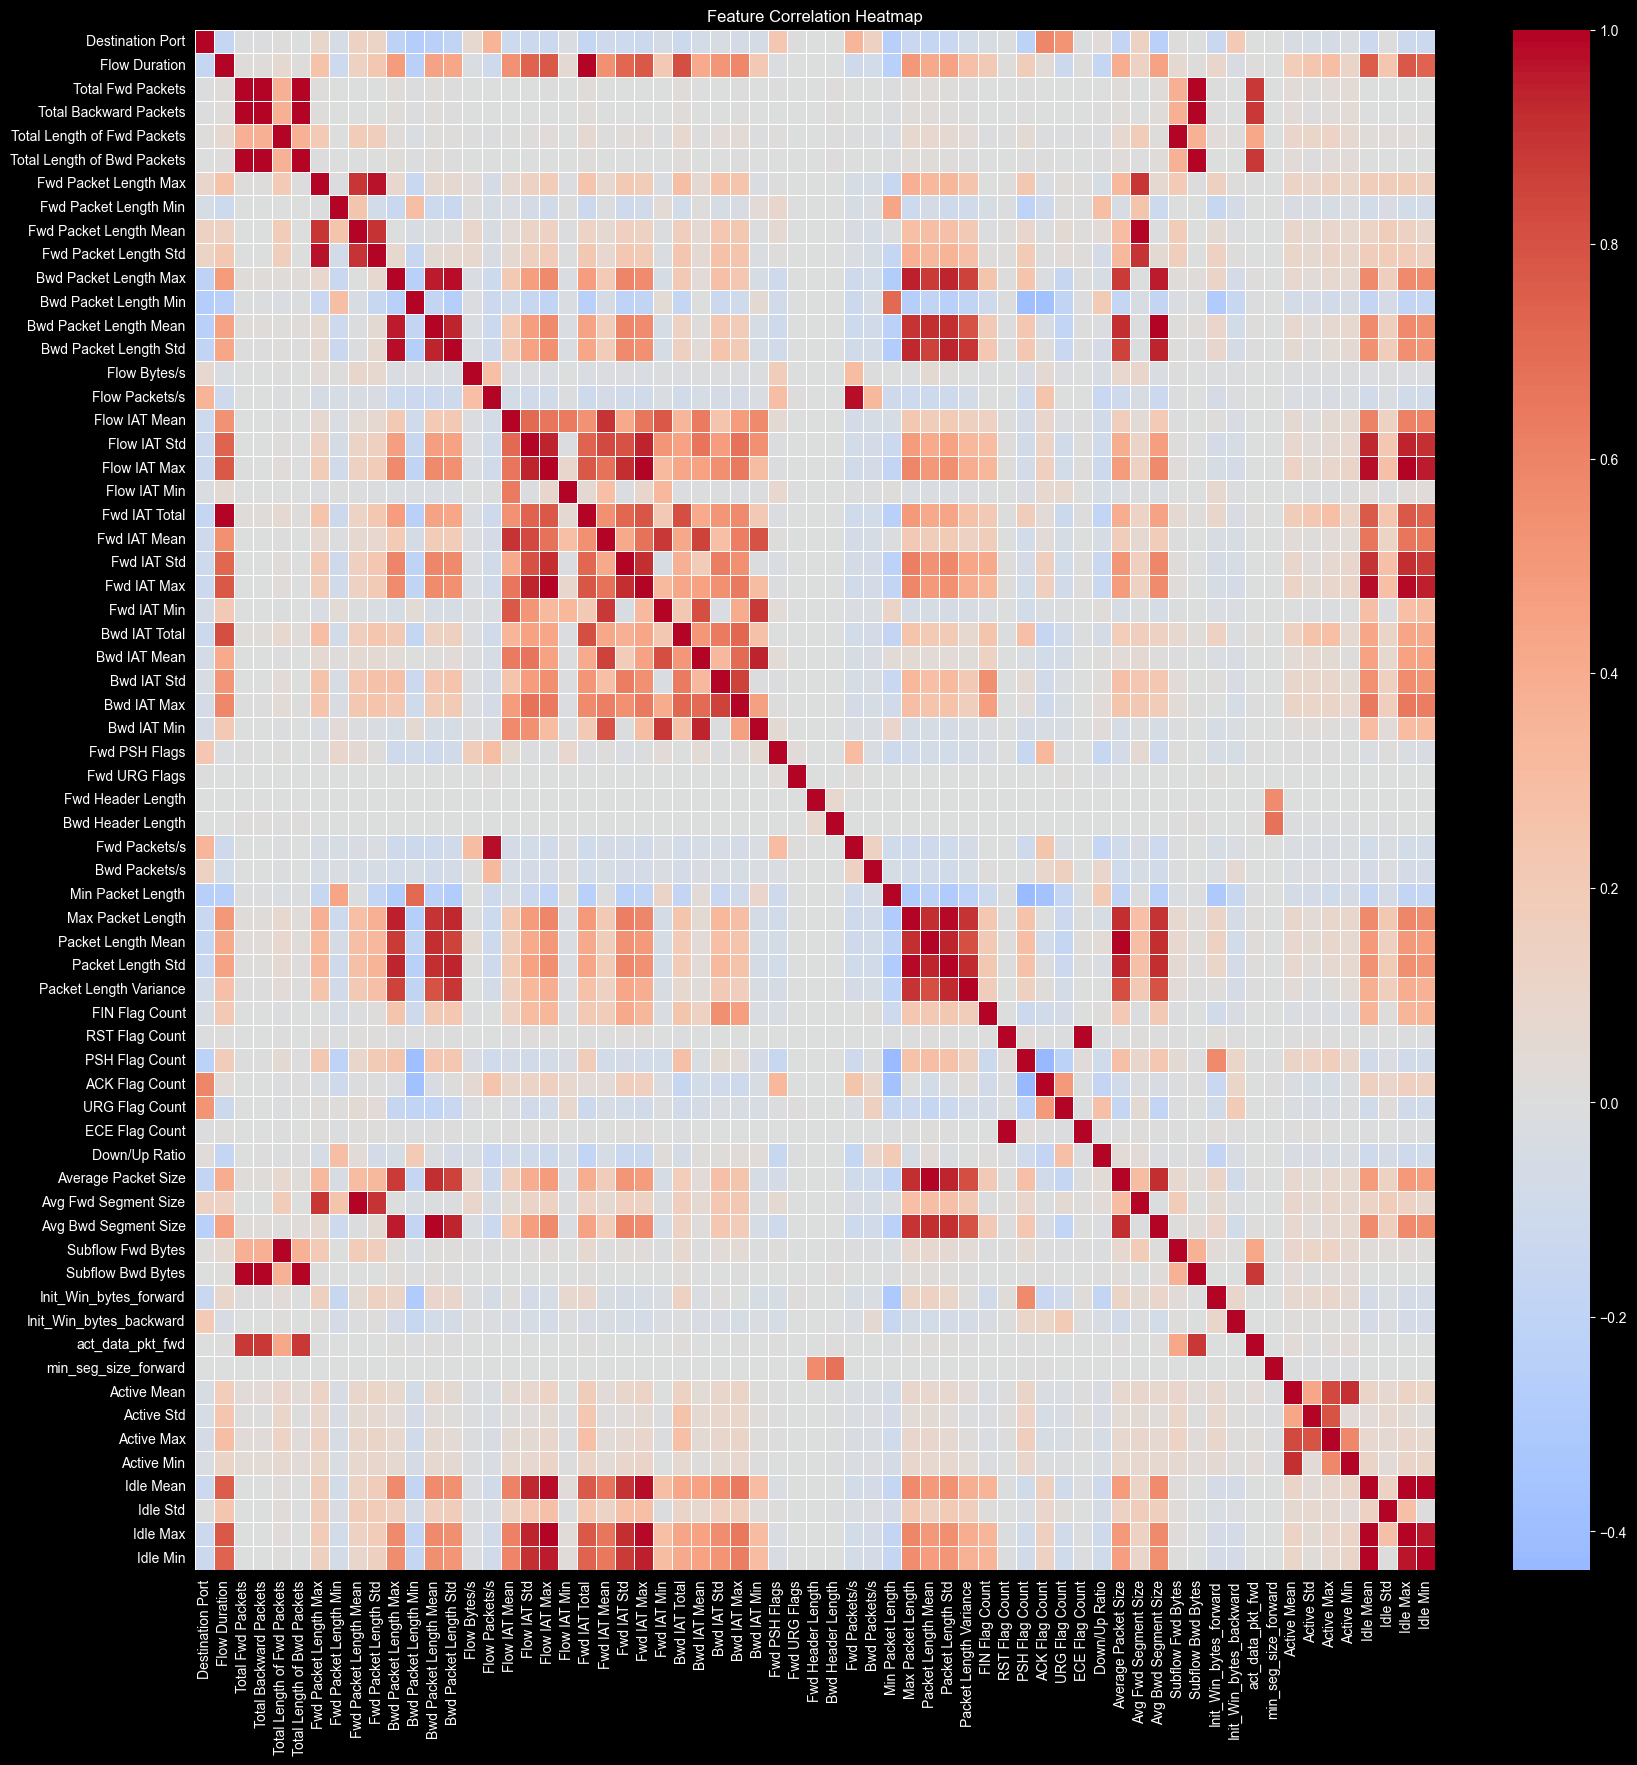

In [35]:
num_feat, cate_feat = get_feat_type(data)
high_corr = corre_anlysis(data, num_feat)

In [36]:
for item in high_corr:
    print(f'{item[0]} has a high correlation with {item[1]}: {item[2]:.4f}')

high_multicollinearity = [item for item in high_corr if item[2] >= 0.95]

Flow Duration has a high correlation with Fwd IAT Total: 0.9985
Total Fwd Packets has a high correlation with Total Backward Packets: 0.9991
Total Fwd Packets has a high correlation with Total Length of Bwd Packets: 0.9970
Total Fwd Packets has a high correlation with Subflow Bwd Bytes: 0.9970
Total Fwd Packets has a high correlation with act_data_pkt_fwd: 0.8874
Total Backward Packets has a high correlation with Total Length of Bwd Packets: 0.9945
Total Backward Packets has a high correlation with Subflow Bwd Bytes: 0.9944
Total Backward Packets has a high correlation with act_data_pkt_fwd: 0.8826
Total Length of Fwd Packets has a high correlation with Subflow Fwd Bytes: 1.0000
Total Length of Bwd Packets has a high correlation with Subflow Bwd Bytes: 1.0000
Total Length of Bwd Packets has a high correlation with act_data_pkt_fwd: 0.8840
Fwd Packet Length Max has a high correlation with Fwd Packet Length Mean: 0.8890
Fwd Packet Length Max has a high correlation with Fwd Packet Length 

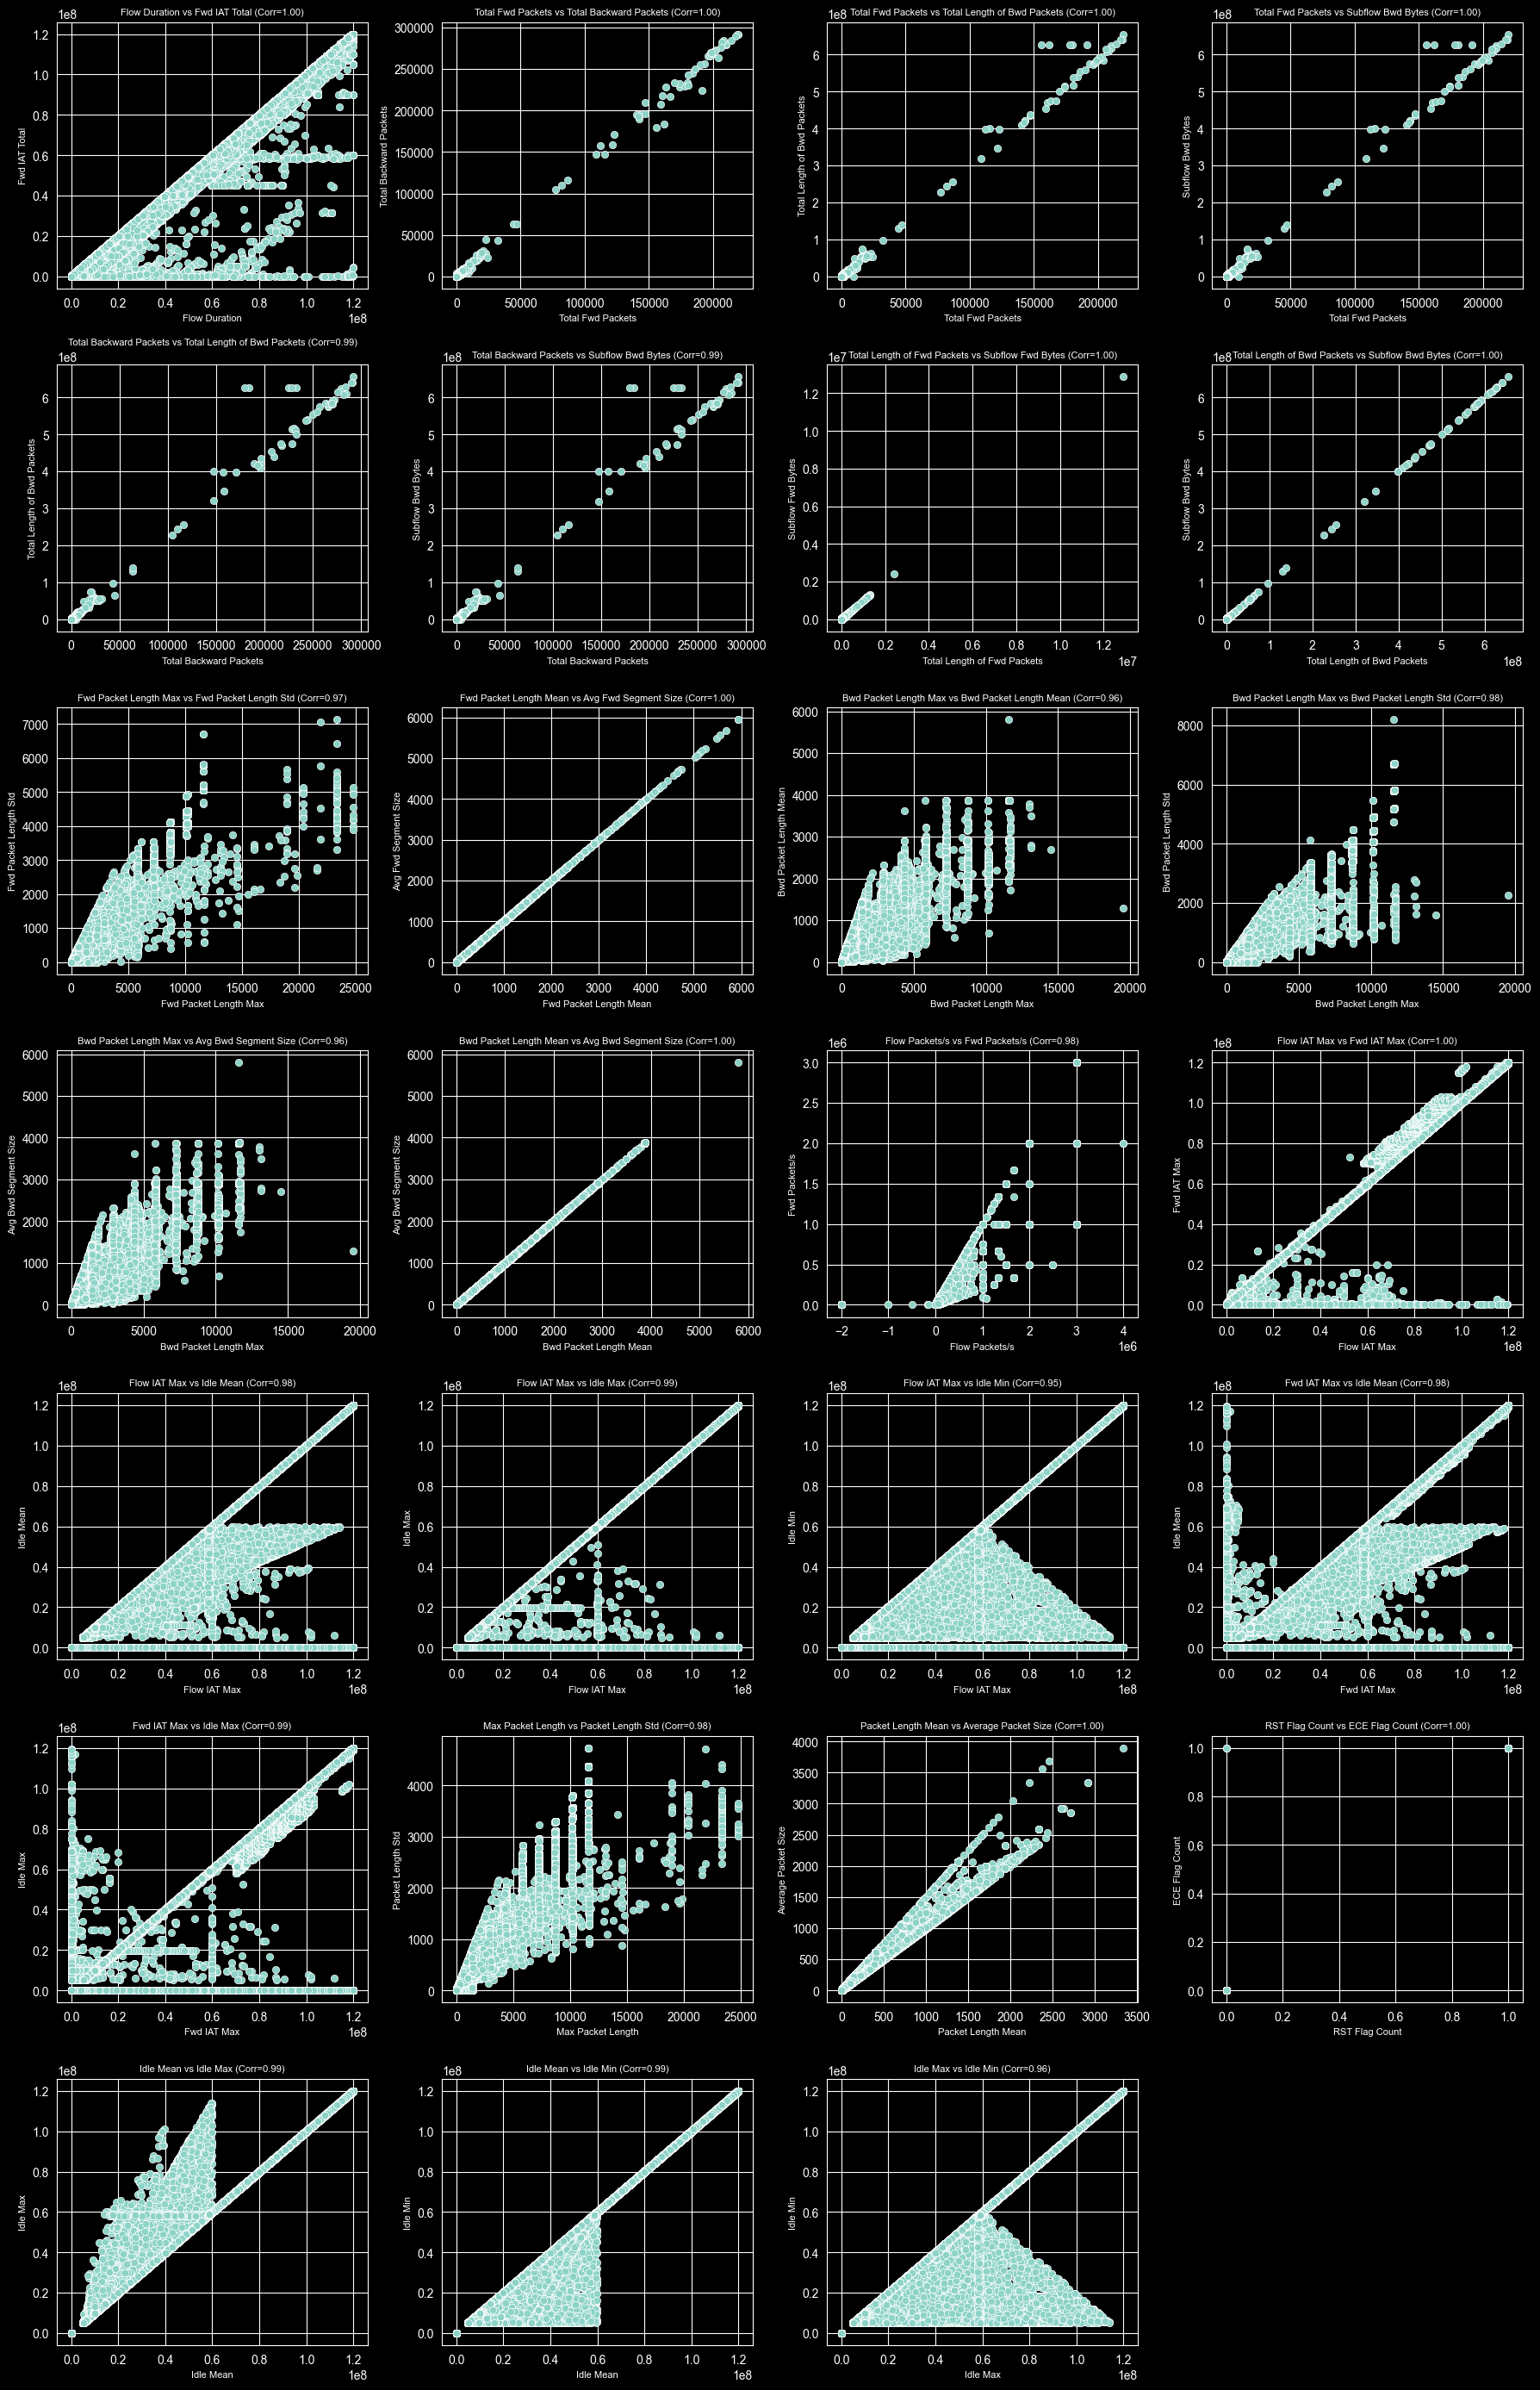

In [37]:
n_plots = len(high_multicollinearity)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, (feat_x, feat_y, corr_val) in enumerate(high_multicollinearity):
    sns.scatterplot(x=data[feat_x], y=data[feat_y], ax=axes[i])
    axes[i].set_title(f'{feat_x} vs {feat_y} (Corr={corr_val:.2f})', fontsize=8)
    axes[i].set_xlabel(feat_x, fontsize=8)
    axes[i].set_ylabel(feat_y, fontsize=8)

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Dựa trên các biểu đồ phân tán, có thể quan sát thấy một số cặp đặc trưng có mối quan hệ tuyến tính gần như hoàn hảo.
Việc giữ lại đồng thời các đặc trưng này không mang lại nhiều thông tin bổ sung mà còn có thể gây bất ổn cho mô hình học máy.

Do đó, một số đặc trưng đại diện sẽ được loại bỏ để giảm đa cộng tuyến.

In [38]:
select_cols = ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']

select_cols = [col for col in select_cols if col in data.columns]

if select_cols:
    print(f'Dropping {len(select_cols)} columns: {select_cols}')
    data.drop(columns=select_cols, inplace=True)
else:
    print('No columns to drop (already removed)')
num_feat, cate_feat = get_feat_type(data)
data.shape

Dropping 5 columns: ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']


(2520751, 61)

## 3.3. Outliers
Phân tích outliers được thực hiện với mục đích thăm dò (diagnostic),
không nhằm loại bỏ trực tiếp các giá trị ngoại lai.

Trong bối cảnh dữ liệu mạng (network traffic), các giá trị cực trị có thể mang ý nghĩa quan trọng,
đặc biệt đối với các hành vi tấn công bất thường.
Do đó, outliers được giữ lại để tránh làm mất thông tin có giá trị.

In [39]:
# #% outliers
# outlierPercent = calculate_outliers_percentage(data[num_feat])
# outliers_df = pd.DataFrame.from_dict(outlierPercent, orient='index', columns=['Outlier_Percentage'])
# threshold = 10
# high_outlier_features = outliers_df[outliers_df['Outlier_Percentage'] > threshold]
# outliers_df_sorted = outliers_df.sort_values(by='Outlier_Percentage', ascending=False)

# fig, ax = plt.subplots(figsize=(20, 6))

# colors = np.where(outliers_df_sorted['Outlier_Percentage'].values > threshold, "#ff7f0e", "#1f77b4")
# ax.bar(outliers_df_sorted.index, outliers_df_sorted['Outlier_Percentage'].values,
#        color=colors, edgecolor="black", linewidth=0.3)
# ax.axhline(y=threshold, color="#d62728", linestyle='--', linewidth=1.5, label=f'{threshold}% Threshold')
# ax.set_xlabel('Features')
# ax.set_ylabel('Percentage of Outliers')
# ax.set_title('Percentage of Outliers for Each Feature with Threshold')
# ax.legend()
# ax.tick_params(axis='x', labelrotation=90)
# plt.tight_layout()
# plt.show()


# print(f"Features with outlier percentage above {threshold}%:\n")
# print(high_outlier_features.sort_values('Outlier_Percentage', ascending=False))
# if 'outliers_df' in locals():
#     del outliers_df


## 3.4. Data Distribution
Kiểm định Anderson-Darling được sử dụng để đánh giá giả thuyết dữ liệu tuân theo phân phối chuẩn.
Kiểm định này phù hợp với tập dữ liệu lớn và nhạy hơn ở phần đuôi phân phối so với các kiểm định khác.

Kết quả cho thấy phần lớn các đặc trưng không tuân theo phân phối chuẩn.

In [40]:
norm_dist = 0
not_norm_dist = 0
norm_features = []
non_norm_features = []

for col in num_feat:
    # Use method='interpolate' to calculate a p-value
    result = stats.anderson(data[col], dist='norm', method='interpolate')

    # Check the p-value against your alpha (0.05)
    # If p > 0.05, we fail to reject the null (it's likely normal)
    if result.pvalue > 0.05:
        norm_dist += 1
        norm_features.append(col)
    else:
        not_norm_dist += 1
        non_norm_features.append(col)

print(f'{norm_dist} features are normally distributed')
print(f'{not_norm_dist} features are not normally distributed - Reject null hypothesis')
print(f'\nPercentage: {(not_norm_dist/len(num_feat)*100):.1f}% are non-normal')

0 features are normally distributed
60 features are not normally distributed - Reject null hypothesis

Percentage: 100.0% are non-normal


## 3.5. Class Imbalance

In [41]:
att_count_df = data['Attack Type'].value_counts().reset_index()
att_count_df.columns = ['Attack Type', 'Number of Occurrences']

att_count_df['% of Total'] = (att_count_df['Number of Occurrences'] / len(data) * 100).round(2)

print(att_count_df)

      Attack Type  Number of Occurrences  % of Total
0  Normal Traffic                2095057       83.11
1             DoS                 193745        7.69
2            DDoS                 128014        5.08
3   Port Scanning                  90694        3.60
4     Brute Force                   9150        0.36
5     Web Attacks                   2143        0.09
6            Bots                   1948        0.08


Phân tích phân phối lớp cho thấy sự mất cân bằng rõ rệt trong bộ dữ liệu CICIDS2017.

- Lớp Normal Traffic (BENIGN) chiếm tỷ lệ áp đảo (~83%)
- Các lớp tấn công, ngay cả những lớp phổ biến như DoS, vẫn có số lượng mẫu thấp hơn đáng kể
- Một số lớp sau khi gộp vẫn thuộc nhóm thiểu số (Bots, Web Attacks, Brute Force)

### Các vấn đề tiềm ẩn
- **Model Bias**: Mô hình có xu hướng ưu tiên dự đoán lớp đa số
- **Đánh giá sai lệch**: Accuracy cao nhưng recall/precision thấp cho lớp thiểu số

### Định hướng xử lý trong giai đoạn huấn luyện
- Áp dụng class weights
- Sử dụng các mô hình ensemble
- Đánh giá bằng các chỉ số phù hợp (F1-score, recall, ROC-AUC)
- Cân nhắc SMOTE hoặc undersampling trong pipeline huấn luyện


Kết quả phân tích khám phá dữ liệu cho thấy:
- Phần lớn các đặc trưng không tuân theo phân phối chuẩn
- Sự tồn tại của đa cộng tuyến và outliers là đáng kể
- Dữ liệu có mức độ mất cân bằng lớp cao

Những đặc điểm này cho thấy việc sử dụng các phương pháp thống kê phi tham số
và các mô hình ensemble là lựa chọn phù hợp cho các bước phân tích tiếp theo.

In [42]:
# Cleaning up
if 'att_count_df' in locals():
    del att_count_df

# 5. Feature Importance
Hai hướng tiếp cận được sử dụng song song:
- Phương pháp thống kê phi tham số (Kruskal–Wallis test)
- Phương pháp dựa trên mô hình học máy (Random Forest)

Việc kết hợp hai phương pháp giúp tăng độ tin cậy và khả năng diễn giải của kết quả.

In [43]:
variance_result = analyze_variance_homogeneity(data, num_feat)

Skipping Levene's test for feature: Fwd URG Flags (insufficient valid groups)
Skipping Levene's test for feature: RST Flag Count (insufficient valid groups)
Skipping Levene's test for feature: ECE Flag Count (insufficient valid groups)


In [44]:
significant_features = {f: r for f, r in variance_result.items() if r['p-value'] <= 0.05}
non_significant_features = {f: r for f, r in variance_result.items() if r['p-value'] > 0.05}

total_features = len(variance_result)
significant_count = len(significant_features)
non_significant_count = len(non_significant_features)

print(f"Variance Homogeneity Analysis Summary:")
print(f"{'='*50}")
print(f"Total features analyzed: {total_features}")
print(f"Significant variance differences (p ≤ 0.05): {significant_count} ({significant_count/total_features*100:.1f}%)")
print(f"Non-significant variance differences (p > 0.05): {non_significant_count} ({non_significant_count/total_features*100:.1f}%)")

if non_significant_features:
    print(f"\n{'='*50}")
    print(f"Features with homogeneous variances (p > 0.05):")
    print(f"{'='*50}")
    
    sorted_non_sig = sorted(non_significant_features.items(), key=lambda x: x[1]['p-value'], reverse=True)
    
    for feature, result in sorted_non_sig:
        print(f"\n  • {feature}")
        print(f"    Statistic: {result['Statistic']:.4f} | p-value: {result['p-value']:.4f}")
        print(f"    → Variances are NOT significantly different")
else:
    print(f"\n{'='*50}")
    print("All features show significant variance differences across groups.")
    print("→ Kruskal-Wallis test is appropriate (non-parametric).")

Variance Homogeneity Analysis Summary:
Total features analyzed: 57
Significant variance differences (p ≤ 0.05): 54 (94.7%)
Non-significant variance differences (p > 0.05): 3 (5.3%)

Features with homogeneous variances (p > 0.05):

  • Fwd Header Length
    Statistic: 0.1504 | p-value: 0.9890
    → Variances are NOT significantly different

  • Bwd Header Length
    Statistic: 0.3305 | p-value: 0.9213
    → Variances are NOT significantly different

  • min_seg_size_forward
    Statistic: 0.6496 | p-value: 0.6271
    → Variances are NOT significantly different


 Kết quả đánh giá nêu trên (chỉ có 3 đặc trưng không bác bỏ được giả thuyết không), kết hợp với các thông tin về phân phối, đã cho thấy việc sử dụng kiểm định phân tích phương sai một yếu tố (One-Way ANOVA) là không hợp lệ. Do đó, phương pháp phù hợp hơn là kiểm định Kruskal-Wallis; đây là một giải pháp thay thế phi tham số, không yêu cầu giả định về sự bằng nhau của các phương sai và có tính vững (robust) đối với các vi phạm về tính chuẩn hoặc tính đồng nhất phương sai."

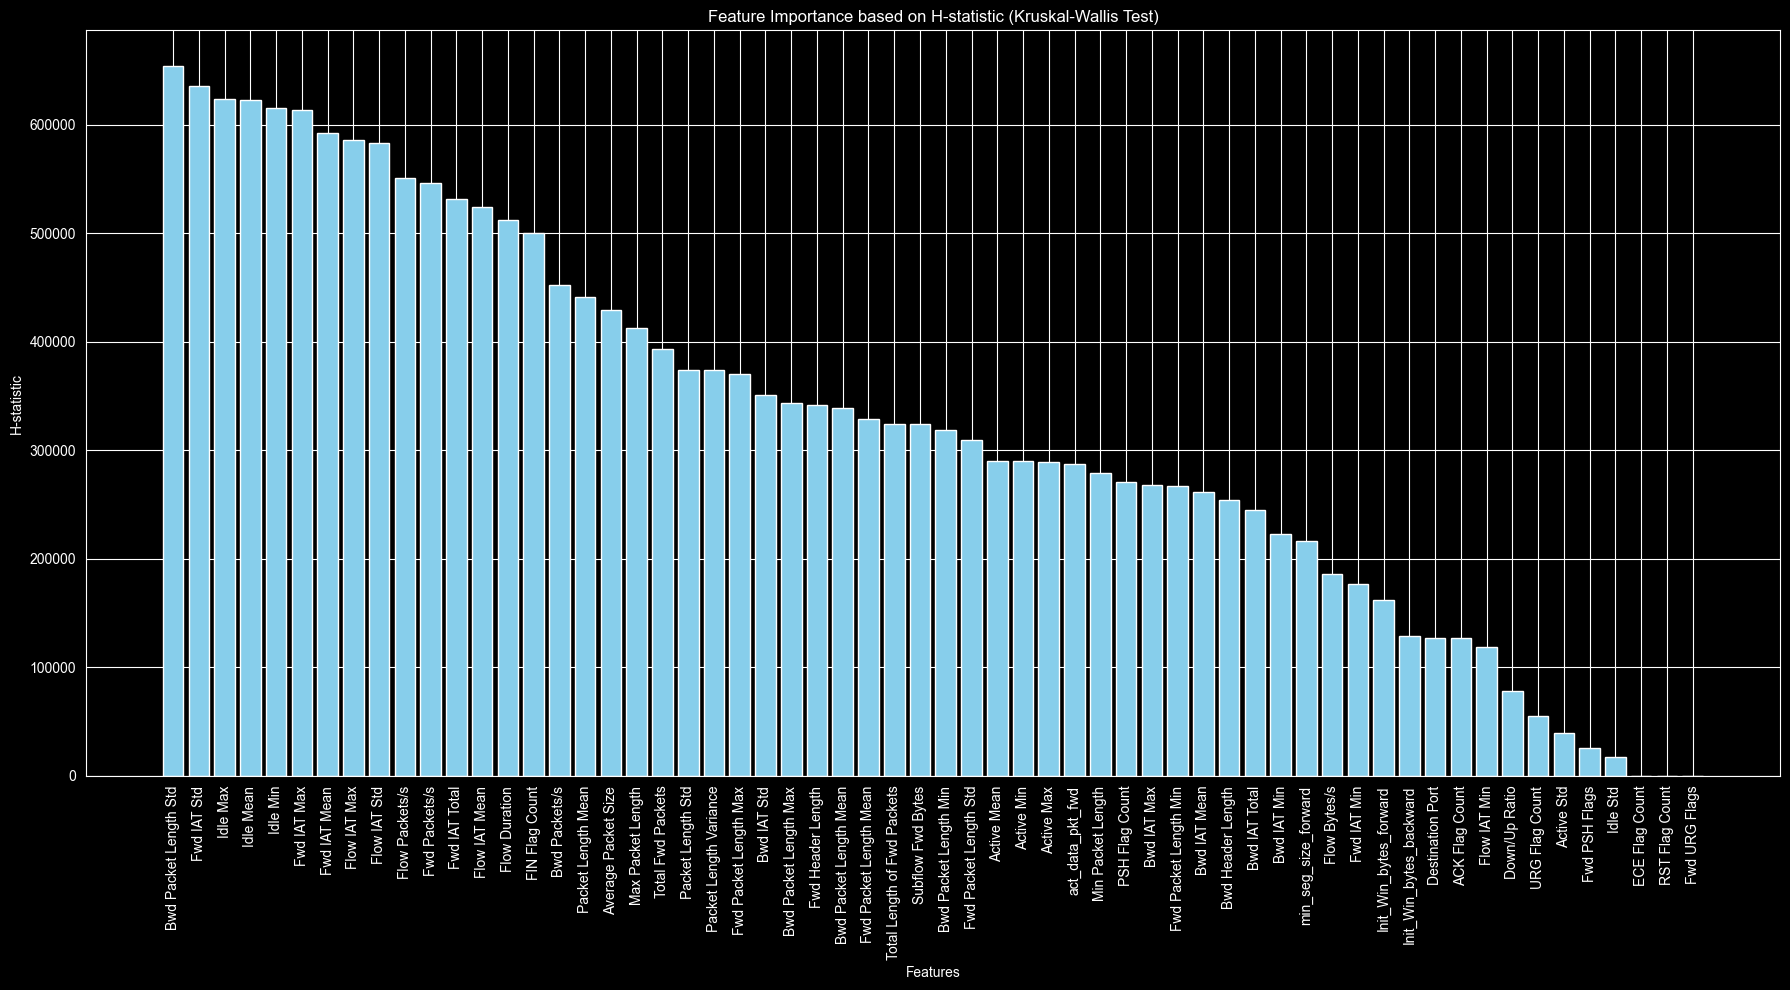

In [45]:
h_p_stats = analyze_feature_importance(data, num_feat)

Cross-Validation Score: 0.9987 ± 0.0001

Classification Report:

                precision    recall  f1-score   support

          Bots       0.86      0.47      0.61       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.97      0.98       643

      accuracy                           1.00    756226
     macro avg       0.98      0.92      0.94    756226
  weighted avg       1.00      1.00      1.00    756226




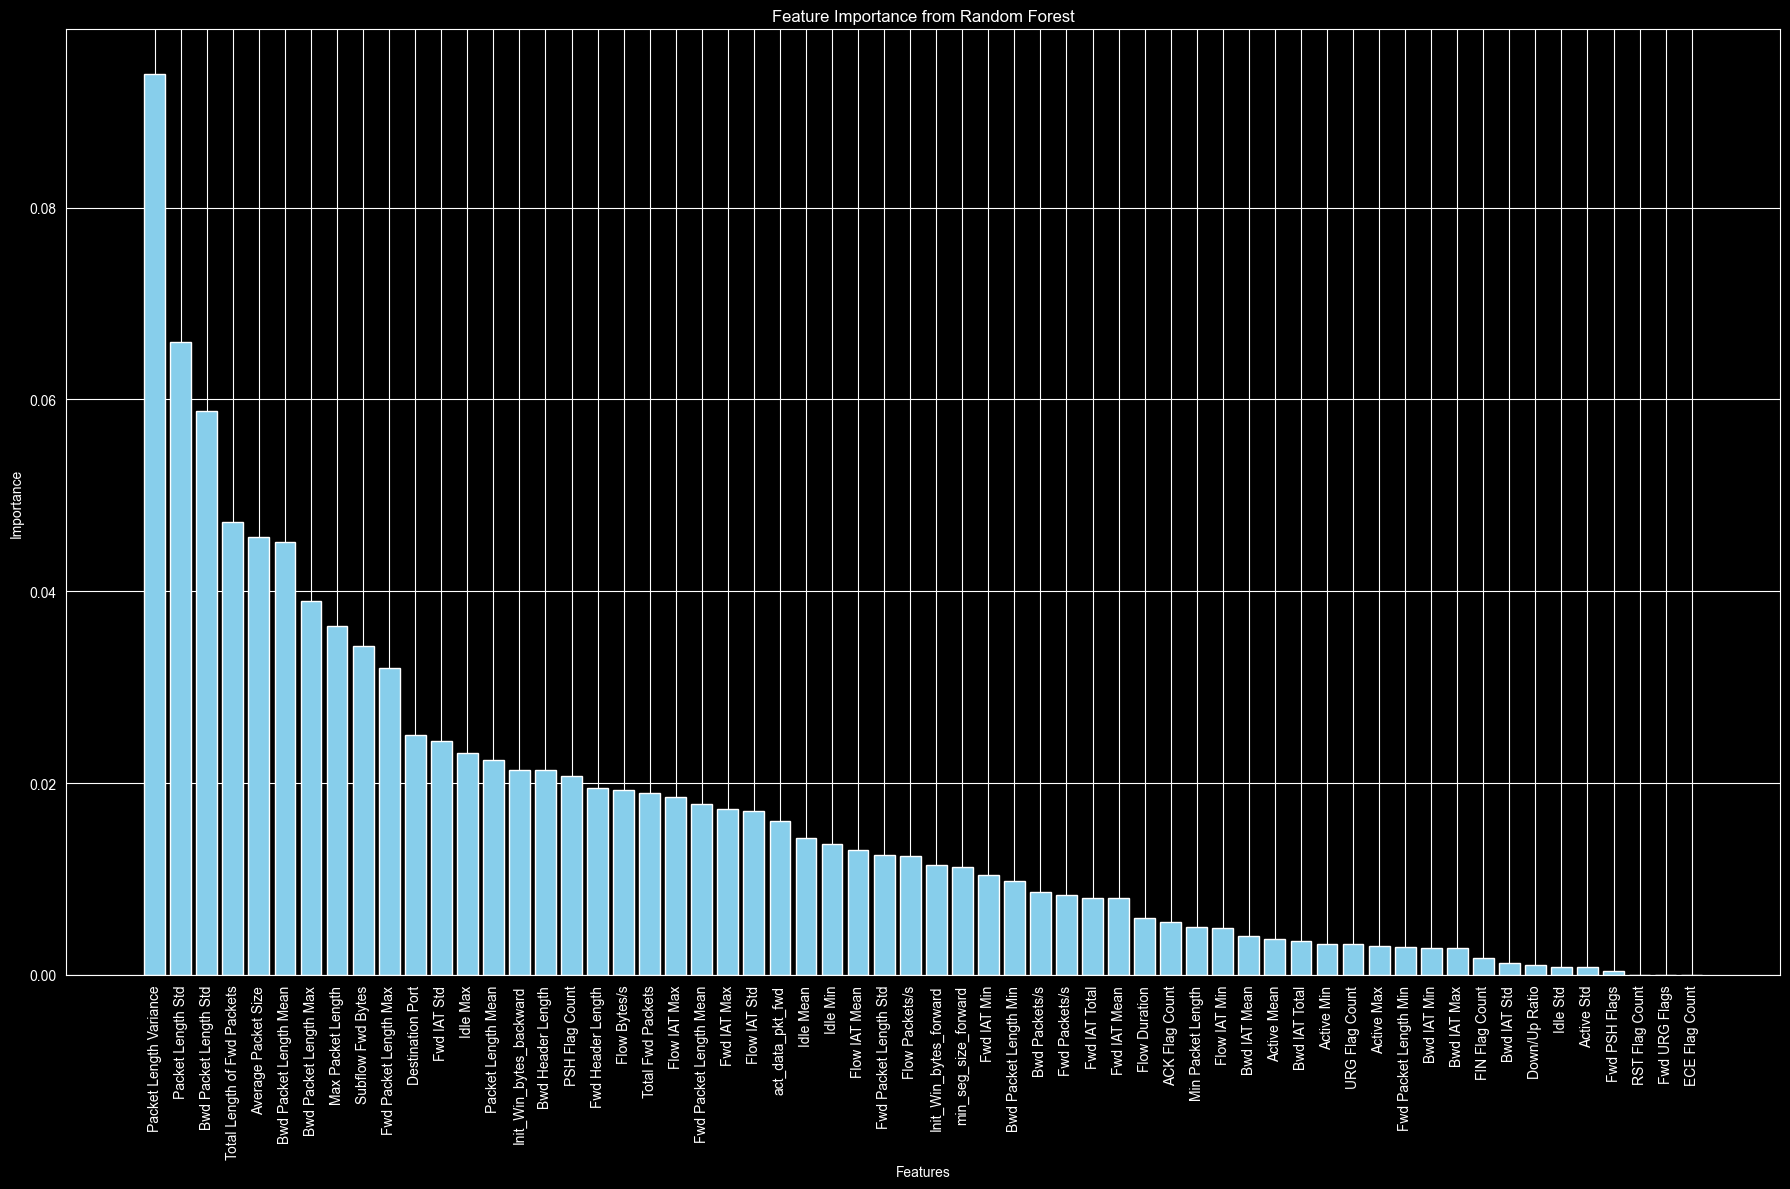

In [46]:
feature_importance_tree, cm, rf_labels, cv_scores = analyze_feature_importance_rf(data, num_feat)

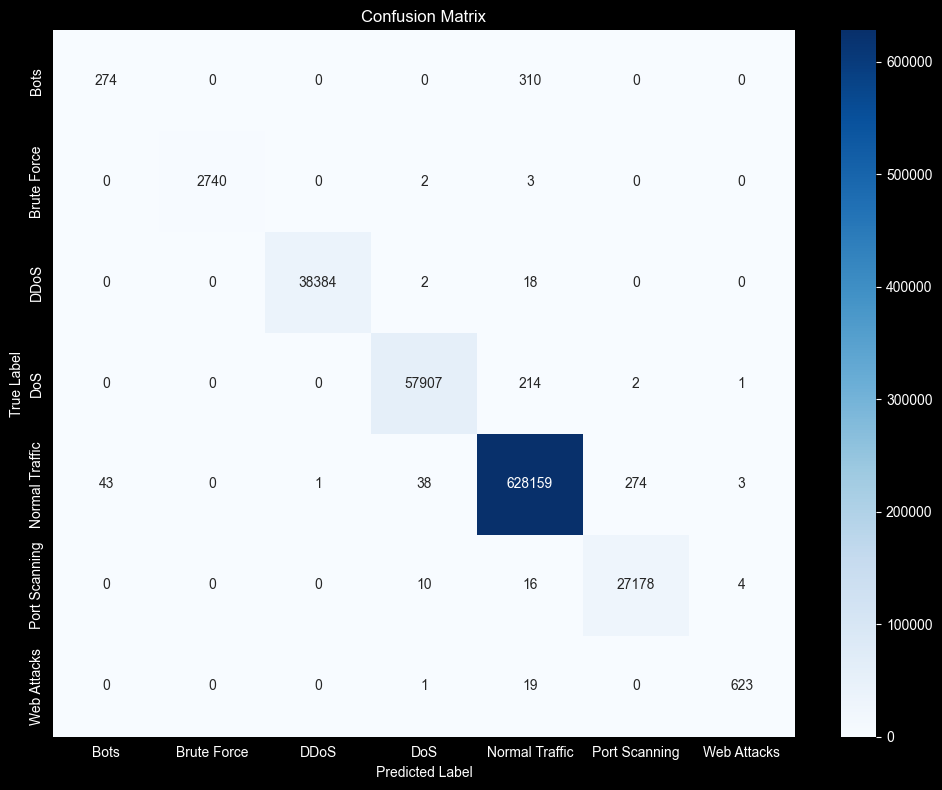

In [47]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_labels, yticklabels=rf_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

"Sau khi đánh giá hiệu năng của mô hình Random Forest, chúng tôi ghi nhận kết quả tổng thể khả quan, cho thấy sự phù hợp của mô hình này đối với việc phân tích tầm quan trọng của các đặc trưng. Tuy nhiên, ma trận nhầm lẫn (confusion matrix) và báo cáo phân loại (classification report) đã bộc lộ một điểm yếu đáng chú ý trong việc phân loại các cuộc tấn công Bot, với khoảng 1/4 số trường hợp này bị phân loại sai thành lưu lượng bình thường (điều này không quá ngạc nhiên, xét đến việc đây là lớp dữ liệu thiểu số).

Sự phân loại sai này chỉ ra một khía cạnh tiềm năng cần cải thiện trong mô hình phát hiện xâm nhập hoàn chỉnh của chúng tôi; vấn đề này có thể được giải quyết bằng cách xem xét các phương pháp phát hiện bot nâng cao hơn, kỹ thuật đặc trưng chuyên biệt (specialized feature engineering), cũng như các kỹ thuật cân bằng dữ liệu. Bất chấp hạn chế này, hiệu năng tổng thể vẫn đảm bảo tính hợp lý khi sử dụng các điểm số quan trọng của đặc trưng từ Random Forest như một tham chiếu giá trị để so sánh với thống kê H của kiểm định Kruskal-Wallis trong quy trình chọn lọc đặc trưng tiếp theo."

In [48]:
h_p_stats = h_p_stats.reset_index()
h_p_stats = h_p_stats.rename(columns={'index': 'Feature'})


comp_tb = feature_importance_tree.merge(h_p_stats, on='Feature', how='left')
comp_tb_sorted = comp_tb.sort_values(by='Importance', ascending=False)
comp_tb_sorted

,Feature,Importance,H-statistic,p-value
0,Packet Length Variance,9.387163e-02,373845.434316,0.000000e+00
1,Packet Length Std,6.601342e-02,373896.560353,0.000000e+00
2,Bwd Packet Length Std,5.878555e-02,654400.346609,0.000000e+00
3,Total Length of Fwd Packets,4.720259e-02,324367.440051,0.000000e+00
4,Average Packet Size,4.563199e-02,429097.080675,0.000000e+00
5,Bwd Packet Length Mean,4.517260e-02,338820.640791,0.000000e+00
6,Bwd Packet Length Max,3.895501e-02,343538.176327,0.000000e+00
7,Max Packet Length,3.632995e-02,413042.599252,0.000000e+00
8,Subflow Fwd Bytes,3.424406e-02,324367.440051,0.000000e+00
9,Fwd Packet Length Max,3.202516e-02,370387.060527,0.000000e+00


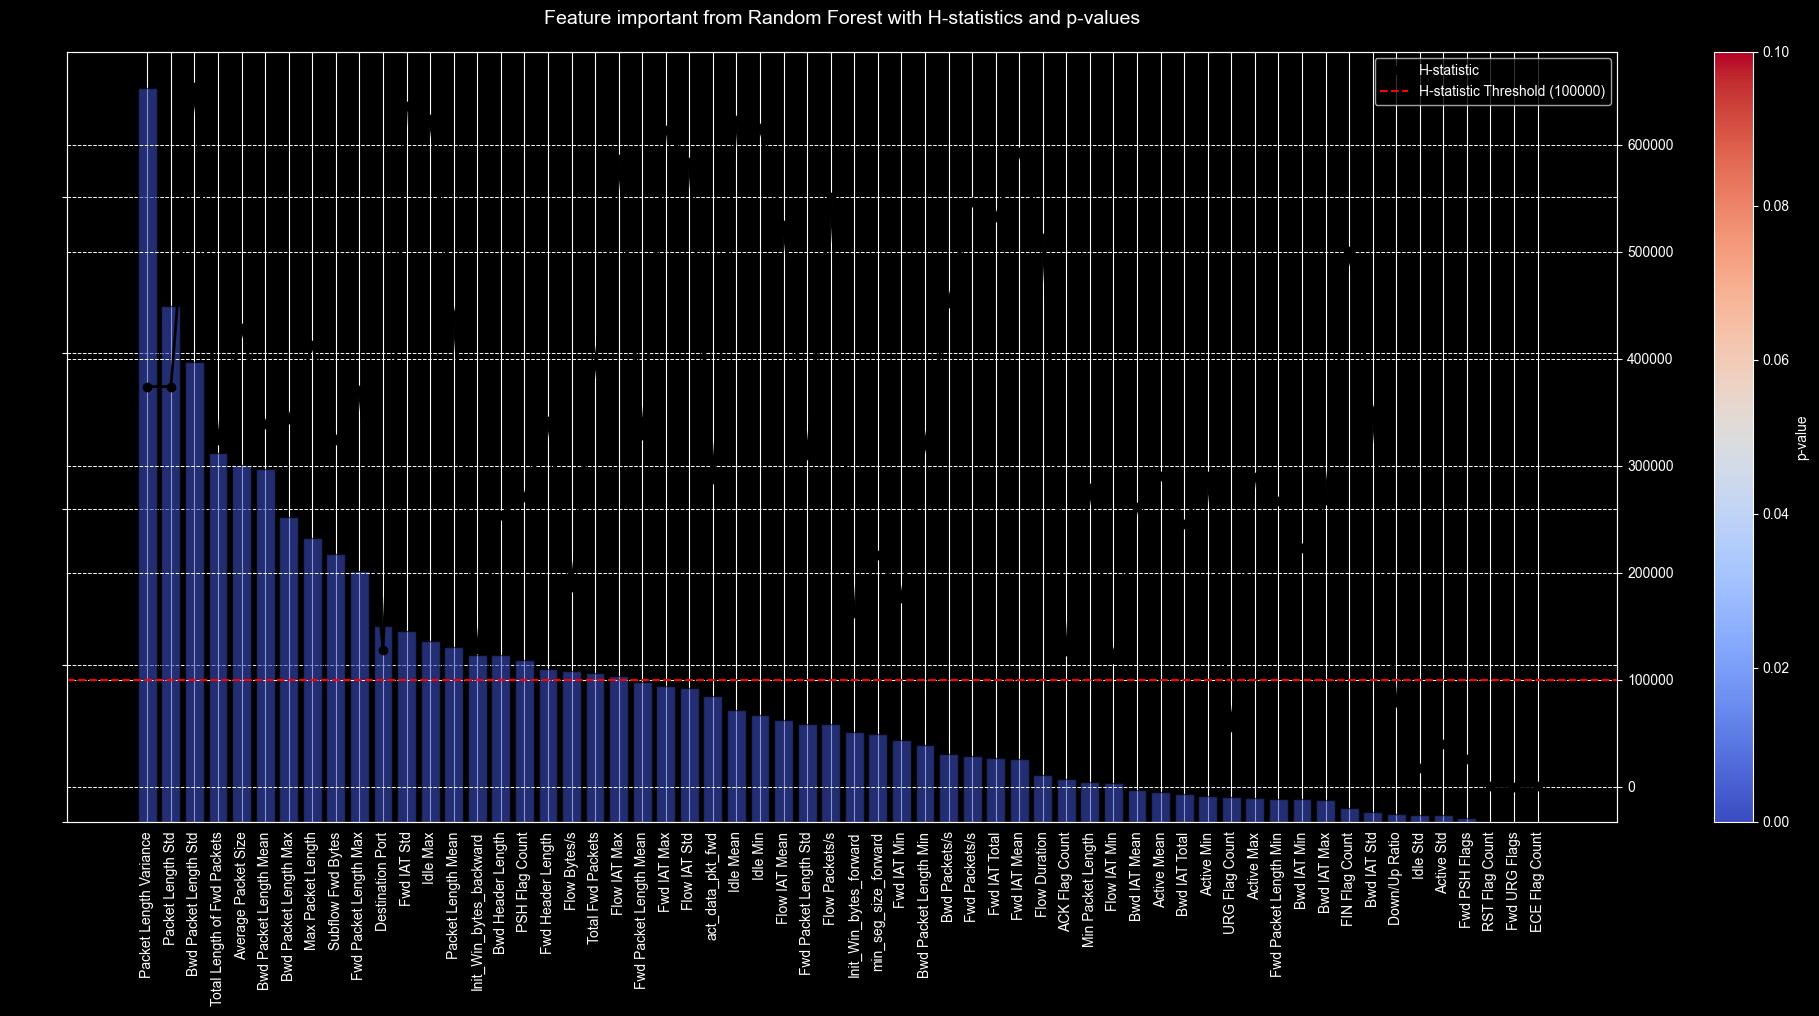

In [49]:
plt.figure(figsize=(25, 10))
colors = sns.color_palette("coolwarm", as_cmap=True)
ax1 = plt.gca()
ax2 = ax1.twinx()

p_values_norm = (comp_tb_sorted['p-value'] - comp_tb_sorted['p-value'].min()) / (0.1 - comp_tb_sorted['p-value'].min())


bars = ax1.bar(comp_tb_sorted['Feature'],
                comp_tb_sorted['Importance'],
                alpha=0.6,
                color=[colors(value) for value in p_values_norm], 
                edgecolor='black')

line = ax2.plot(comp_tb_sorted['Feature'],
                 comp_tb_sorted['H-statistic'],
                 color='black',
                 linewidth=2,
                 label='H-statistic',
                 marker='o')

threshold = 100000
ax2.axhline(y=threshold, color='red', linestyle='--', label=f'H-statistic Threshold ({threshold})')
ax2.legend()

ax1.set_ylabel('Feature Important', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax1.set_xticks(range(len(comp_tb_sorted)))
ax1.set_xticklabels(comp_tb_sorted['Feature'], rotation=90, ha='center', fontsize=10)

plt.title('Feature important from Random Forest with H-statistics and p-values',
          fontsize=14, pad=20)

sm = plt.cm.ScalarMappable(cmap=colors, norm=plt.Normalize(vmin=comp_tb_sorted['p-value'].min(), vmax=0.1))
cbar = plt.colorbar(sm, ax=ax1, orientation='vertical')
cbar.set_label('p-value', fontsize=10)

for ax in [ax1, ax2]:
    ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)

plt.show()

Kết luận biểu đồ minh họa: một số đặc trưng được mô hình Random Forest lựa chọn có chỉ số thống kê H (H-statistics) thấp hơn, thì những đặc trưng quan trọng nhất lại nằm trong phạm vi tập trung các giá trị thống kê H cao nhất. Tuy nhiên, thông tin đáng chú ý nhất lại nằm ở phía đuôi phải, nơi có sự hội tụ của các đặc trưng có mức độ ưu tiên thấp nhất và mức độ liên quan theo thống kê H gần như bằng không. Dựa trên những kết quả này, các đặc trưng ít quan trọng nhất sẽ bị loại bỏ khỏi bộ dữ liệu, điều này giúp:


1. Cải thiện hiệu quả mô hình: Việc huấn luyện với ít đặc trưng hơn sẽ làm giảm chi phí tính toán (cả về thời gian và bộ nhớ)
2. Giảm nhiễu: Loại bỏ các đặc trưng không liên quan đôi khi có thể cải thiện hiệu suất mô hình bằng cách giảm thiểu nhiễu và ngăn chặn hiện tượng quá khớp (overfitting)
3. Đơn giản hóa việc diễn giải: Các mô hình với số lượng đặc trưng ít hơn thường dễ hiểu và giải thích hơn.


In [50]:
cols_to_remove = ['ECE Flag Count','RST Flag Count', 'Fwd URG Flags', 'Idle Std', 'Fwd PSH Flags', 'Active Std', 'Down/Up Ratio', 'URG Flag Count']
data.drop(columns=cols_to_remove, inplace=True)

In [51]:
print("\n" + "="*70)
print("Top 20 most important features (Random Forest)")
print("="*70)
for idx, (_, row) in enumerate(feature_importance_tree.head(20).iterrows(), 1):
    print(f"{idx:2d}. {row['Feature']:40s} | Importance: {row['Importance']:.6f}")
print("="*70 + "\n")


Top 20 most important features (Random Forest)
 1. Packet Length Variance                   | Importance: 0.093872
 2. Packet Length Std                        | Importance: 0.066013
 3. Bwd Packet Length Std                    | Importance: 0.058786
 4. Total Length of Fwd Packets              | Importance: 0.047203
 5. Average Packet Size                      | Importance: 0.045632
 6. Bwd Packet Length Mean                   | Importance: 0.045173
 7. Bwd Packet Length Max                    | Importance: 0.038955
 8. Max Packet Length                        | Importance: 0.036330
 9. Subflow Fwd Bytes                        | Importance: 0.034244
10. Fwd Packet Length Max                    | Importance: 0.032025
11. Destination Port                         | Importance: 0.025031
12. Fwd IAT Std                              | Importance: 0.024341
13. Idle Max                                 | Importance: 0.023115
14. Packet Length Mean                       | Importance: 0.022399


## 5.1. Tổng quan các feature cuối cùng để huấn luyện

| **Column Name**                    | **Description**                                                                                                                                             |
|-------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Destination Port                    | Cổng đích của luồng dữ liệu (flow).                                                                                                                         |
| Flow Duration                       | Thời lượng của luồng dữ liệu.                                                                                                                                   |
| Total Fwd Packets                   | Tổng số lượng gói tin chiều đi (forward) trong luồng                                                                                                      |
| Total Length of Fwd Packets         | Tổng độ dài của các gói tin chiều đi trong luồng                                                                                                         |
| Fwd Packet Length Max               | Kích thước lớn nhất của gói tin chiều đi                                                                                                                    |
| Fwd Packet Length Min               | The minimum size of forwarded packets.                                                                                                                     |
| Fwd Packet Length Mean              | The average length of forwarded packets in the flow.                                                                                                       |
| Fwd Packet Length Std               | The standard deviation of forwarded packet lengths in the flow.                                                                                           |
| Bwd Packet Length Max               | The maximum size of backward packets.                                                                                                                       |
| Bwd Packet Length Min               | The minimum size of backward packets.                                                                                                                     |
| Bwd Packet Length Mean              | The average size of backward packets.                                                                                                                       |
| Bwd Packet Length Std               | The standard deviation of backward packet lengths in the flow.                                                                                             |
| Flow Bytes/s                        | The number of bytes transferred per second in the flow.                                                                                                   |
| Flow Packets/s                      | The number of packets transferred per second in the flow.                                                                                                  |
| Flow IAT Mean                       | The average inter-arrival time of packets in the flow.                                                                                                     |
| Flow IAT Std                        | The standard deviation of the inter-arrival times of packets in the flow.                                                                                  |
| Flow IAT Max                        | The maximum inter-arrival time of packets in the flow.                                                                                                      |
| Flow IAT Min                        | The minimum inter-arrival time of packets in the flow.                                                                                                     |
| Fwd IAT Total                       | The total forward inter-arrival time observed during the flow.                                                                                             |
| Fwd IAT Mean                        | The mean forward inter-arrival time observed during the flow.                                                                                              |
| Fwd IAT Std                         | The standard deviation of the forward inter-arrival time during the flow.                                                                                 |
| Fwd IAT Max                         | The maximum forward inter-arrival time observed during the flow.                                                                                           |
| Fwd IAT Min                         | The minimum forward inter-arrival time observed during the flow.                                                                                           |
| Bwd IAT Total                       | The total backward inter-arrival time during the flow.                                                                                                    |
| Bwd IAT Mean                        | The average backward inter-arrival time during the flow.                                                                                                  |
| Bwd IAT Std                         | The standard deviation of the backward inter-arrival time during the flow.                                                                                 |
| Bwd IAT Max                         | The maximum backward inter-arrival time during the flow.                                                                                                  |
| Bwd IAT Min                         | The minimum backward inter-arrival time during the flow.                                                                                                  |
| Fwd Header Length                   | The total length of the header in forwarded packets.                                                                                                       |
| Bwd Header Length                   | The total length of the header in backward packets.                                                                                                        |
| Fwd Packets/s                       | The number of forwarded packets transferred per second in the flow.                                                                                        |
| Bwd Packets/s                       | The number of backward packets transferred per second in the flow.                                                                                        |
| Min Packet Length                   | The minimum packet length observed in the flow.                                                                                                            |
| Max Packet Length                   | The maximum packet length observed in the flow.                                                                                                            |
| Packet Length Mean                  | The average packet length in the flow.                                                                                                                     |
| Packet Length Std                   | The standard deviation of packet lengths in the flow.                                                                                                      |
| Packet Length Variance              | The variance of packet lengths in the flow.                                                                                                                |
| FIN Flag Count                      | The number of FIN flags observed in the flow.                                                                                                               |
| PSH Flag Count                      | The number of PSH flags observed in the flow.                                                                                                               |
| ACK Flag Count                      | The number of ACK flags observed in the flow.                                                                                                               |
| Average Packet Size                 | The average size of the packets in the flow.                                                                                                               |
| Subflow Fwd Bytes                   | The number of bytes in the forwarded subflow.                                                                                                              |
| Init_Win_bytes_forward              | The initial window size in bytes in the forward direction.                                                                                                 |
| Init_Win_bytes_backward             | The initial window size in bytes in the backward direction.                                                                                                |
| act_data_pkt_fwd                    | The number of active data packets forwarded.                                                                                                               |
| min_seg_size_forward                | The minimum segment size forwarded in the flow.                                                                                                            |
| Active Mean                         | The average amount of activity observed during the flow.                                                                                                   |
| Active Max                          | The maximum amount of activity observed during the flow.                                                                                                   |
| Active Min                          | The minimum amount of activity observed during the flow.                                                                                                   |
| Idle Mean                           | The average idle time observed during the flow.                                                                                                            |
| Idle Max                            | The maximum idle time observed during the flow.                                                                                                            |
| Idle Min                            | The minimum idle time observed during the flow.                                                                                                            |
| Attack Type                         | The target class, indicating the type of attack or normal traffic.                                                                                        |


# 6. Outputs

    Lưu ý về các kỹ thuật lấy mẫu và chuẩn hóa:
Việc áp dụng các kỹ thuật tái lấy mẫu và/hoặc chuẩn hóa, chẳng hạn như SMOTE và RobustScaler, trên toàn bộ tập dữ liệu sẽ vi phạm nguyên tắc giữ cho tập kiểm tra (test set) hoàn toàn chưa được nhìn thấy trong quá trình huấn luyện mô hình. Điều này có thể dẫn đến các chỉ số hiệu năng lạc quan quá mức, vì mô hình có thể gián tiếp tiếp nhận thông tin từ tập test trong lúc huấn luyện.

Dựa trên phân tích được thực hiện trong notebook này, cả hai kỹ thuật đều cho thấy lợi ích khi huấn luyện mô hình. Tuy nhiên, các phương pháp này chỉ sẽ được triển khai trong notebook tiếp theo, tại đó tập dữ liệu sẽ được chia thành tập huấn luyện và tập kiểm tra, với trọng tâm là huấn luyện và so sánh các mô hình học máy.

In [52]:
data.to_csv('cicids2017_cleaned.csv', index=False)